# TFG: Detección precoz de cáncer colorrectal utilizando técnicas de aprendizaje automático
**Grado en Física - Universidad Europea de Valencia**

* **Presentado por:** Gabriela Hortensia Ramos Mizrachi
* **Tutor:** Héctor Gisbert Mullor
* **Curso:** 2025-2026

---
### Resumen del Notebook
Este notebook documenta el proceso experimental en el cual se prueba el modelo de aprendizaje automatico, específicamente el análisis de las correlaciones entre diferentes variables de los datos.

# Etapa 2: Optimización mediante aprendizaje automático: 
## Análisis de correlaciones

### Importación de Librerías y Dependencias
En esta sección se cargan todas las herramientas necesarias para el proyecto:

In [ ]:

import os
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, HTML

### Procesamiento de Poblaciones (M, S, P) y Cálculo de Correlaciones
En esta celda se realiza el flujo principal de procesamiento de datos para tres poblaciones distintas:

**Población 'M' (Modelo/Control):** - Lee archivos `.xlsx` que comienzan con "M".
   - Localiza la sección de datos bajo el encabezado 'Library/ID'.
   - Extrae y limpia los nombres de la quinta columna.
   - Identifica los 25 nombres más frecuentes para definir las variables principales.
   - Crea una tabla pivote y calcula la **matriz de correlación** para esta población.

**Población 'S' y 'P':**
   - Repite el proceso de extracción para archivos que comienzan con "S (" y "P (".
   - Filtra los datos para mantener únicamente los mismos 25 nombres principales identificados en la población 'M'.
   - Genera sus respectivas matrices de correlación.

In [ ]:
# Inicializar DataFrame para la población M
all_counts_m = pd.DataFrame()

# Procesar archivos 'M'
for file_name in os.listdir():
    if file_name.startswith('M (') and file_name.endswith('.xlsx'):
        df = pd.read_excel(file_name, sheet_name=0)

        # Encontrar la fila que contiene 'Library/ID'
        library_id_rows = df.apply(lambda row: row.astype(str).str.contains('Library/ID', case=False, na=False)).any(axis=1)
        library_id_index = library_id_rows[library_id_rows == True].index[0]

        # Extraer filas debajo del encabezado 'Library/ID'
        names_data = df.iloc[library_id_index + 1:, :]
        name_column = names_data.iloc[:, 4]  # Asumiendo que la 5ta columna tiene los nombres

        # Obtener nombres únicos y contar cada uno como 1 por archivo
        unique_names = pd.DataFrame({'Name': name_column.unique(), 'Count': 1})
        unique_names['File'] = file_name

        # Añadir al DataFrame principal
        all_counts_m = pd.concat([all_counts_m, unique_names], ignore_index=True)

# Limpiar nombres en 'M'
all_counts_m['Name'] = all_counts_m['Name'].fillna('').astype(str).apply(lambda x: x.split('$$')[0].strip())

# Agregar conteos para 'M'
grouped_m = all_counts_m.groupby(['File', 'Name'])['Count'].sum().reset_index()

# Obtener los 25 nombres más frecuentes para 'M'
top_names_m = grouped_m.groupby('Name')['Count'].sum().nlargest(25).index

# Tabla pivote para 'M'
pivot_m = grouped_m[grouped_m['Name'].isin(top_names_m)].pivot(index='File', columns='Name', values='Count').fillna(0)

# Matriz de correlación para 'M'
correlation_matrix_m = pivot_m.corr()

# Inicializar DataFrame para la población S
all_counts_s = pd.DataFrame()

# Procesar archivos 'S'
for file_name in os.listdir():
    if file_name.startswith('S (') and file_name.endswith('.xlsx'):
        df = pd.read_excel(file_name, sheet_name=0)

        # Encontrar la fila que contiene 'Library/ID'
        library_id_rows = df.apply(lambda row: row.astype(str).str.contains('Library/ID', case=False, na=False)).any(axis=1)
        library_id_index = library_id_rows[library_id_rows == True].index[0]

        # Extraer filas debajo del encabezado 'Library/ID'
        names_data = df.iloc[library_id_index + 1:, :]
        name_column = names_data.iloc[:, 4] 

        # Obtener nombres únicos y contar cada uno como 1 por archivo
        unique_names = pd.DataFrame({'Name': name_column.unique(), 'Count': 1})
        unique_names['File'] = file_name

        # Añadir al DataFrame principal
        all_counts_s = pd.concat([all_counts_s, unique_names], ignore_index=True)

# Limpiar nombres en 'S'
all_counts_s['Name'] = all_counts_s['Name'].fillna('').astype(str).apply(lambda x: x.split('$$')[0].strip())

# Agregar conteos para 'S'
grouped_s = all_counts_s.groupby(['File', 'Name'])['Count'].sum().reset_index()

# Filtrar 'S' para mantener solo los nombres principales de 'M'
pivot_s = grouped_s[grouped_s['Name'].isin(top_names_m)].pivot(index='File', columns='Name', values='Count').fillna(0)

# Matriz de correlación para 'S'
correlation_matrix_s = pivot_s.corr()

# Inicializar DataFrame para la población P
all_counts_p = pd.DataFrame()

# Procesar archivos 'P'
for file_name in os.listdir():
    if file_name.startswith('P (') and file_name.endswith('.xlsx'):
        df = pd.read_excel(file_name, sheet_name=0)

        # Encontrar la fila que contiene 'Library/ID'
        library_id_rows = df.apply(lambda row: row.astype(str).str.contains('Library/ID', case=False, na=False)).any(axis=1)
        library_id_index = library_id_rows[library_id_rows == True].index[0]

        # Extraer filas debajo del encabezado 'Library/ID'
        names_data = df.iloc[library_id_index + 1:, :]
        name_column = names_data.iloc[:, 4]

        # Obtener nombres únicos y contar cada uno como 1 por archivo
        unique_names = pd.DataFrame({'Name': name_column.unique(), 'Count': 1})
        unique_names['File'] = file_name

        # Añadir al DataFrame principal
        all_counts_p = pd.concat([all_counts_p, unique_names], ignore_index=True)

# Limpiar nombres en 'P'
all_counts_p['Name'] = all_counts_p['Name'].fillna('').astype(str).apply(lambda x: x.split('$$')[0].strip())

# Agregar conteos para 'P'
grouped_p = all_counts_p.groupby(['File', 'Name'])['Count'].sum().reset_index()

# Filtrar 'P' para mantener solo los nombres principales de 'M'
pivot_p = grouped_p[grouped_p['Name'].isin(top_names_m)].pivot(index='File', columns='Name', values='Count').fillna(0)

# Matriz de correlación para 'P'
correlation_matrix_p = pivot_p.corr()

# Calcular la diferencia entre las matrices de correlación
correlation_diff = correlation_matrix_m - correlation_matrix_s
correlation_diff_M_P = correlation_matrix_m - correlation_matrix_p
correlation_diff_S_P = correlation_matrix_s - correlation_matrix_p

In [ ]:
UMBRAL = 0.05
COL_ABUNDANCIA = 3  
COL_CAS = 6     

def extraer_cas_por_archivo(file_name, umbral):
    """Función auxiliar para leer el Excel, filtrar por umbral y extraer los CAS en formato correcto"""
    df = pd.read_excel(file_name, header=None)
    
    # Encontrar la fila que contiene 'Library/ID'
    mask = df.apply(lambda row: row.astype(str).str.contains('Library/ID', case=False, na=False)).any(axis=1)
    if not mask.any(): return set()
    idx_inicio = mask.idxmax()
    
    data = df.iloc[idx_inicio + 1:].copy()
    data[COL_ABUNDANCIA] = pd.to_numeric(data[COL_ABUNDANCIA], errors='coerce')
    
    # Filtrar por abundancia y que el CAS no sea nulo
    filtro = (data[COL_ABUNDANCIA] >= umbral) & (data[COL_CAS].notna())
    
    # Extracción y filtrado del CAS
    def formato_cas_correcto(texto):
        match = re.search(r'\b\d{1,7}-\d{2}-\d\b', str(texto))
        if match:
            cas_extraido = match.group(0)
            # Descartar el CAS inválido "00000000-00-0"
            if cas_extraido == '00000000-00-0':
                return None
            return cas_extraido
        return None

    # Aplicar regex y eliminar los nulos (incluyendo los '0000-00-0' que ahora convertimos en None)
    cas_unicos = data.loc[filtro, COL_CAS].apply(formato_cas_correcto).dropna()
    
    return set(cas_unicos)

all_counts_m = pd.DataFrame()
for file_name in os.listdir():
    if file_name.startswith('M (') and file_name.endswith('.xlsx'):
        cas_muestra = extraer_cas_por_archivo(file_name, UMBRAL)
        unique_cas = pd.DataFrame({'CAS': list(cas_muestra), 'Count': 1})
        unique_cas['File'] = file_name
        all_counts_m = pd.concat([all_counts_m, unique_cas], ignore_index=True)

# Agregar conteos para 'M'
grouped_m = all_counts_m.groupby(['File', 'CAS'])['Count'].sum().reset_index()
# Obtener los 25 CAS más frecuentes para 'M'
top_cas_m = grouped_m.groupby('CAS')['Count'].sum().nlargest(25).index
# Tabla pivote y matriz de correlación para 'M'
pivot_m = grouped_m[grouped_m['CAS'].isin(top_cas_m)].pivot(index='File', columns='CAS', values='Count').fillna(0)
correlation_matrix_m = pivot_m.corr()

all_counts_s = pd.DataFrame()
for file_name in os.listdir():
    if file_name.startswith('S (') and file_name.endswith('.xlsx'):
        cas_muestra = extraer_cas_por_archivo(file_name, UMBRAL)
        unique_cas = pd.DataFrame({'CAS': list(cas_muestra), 'Count': 1})
        unique_cas['File'] = file_name
        all_counts_s = pd.concat([all_counts_s, unique_cas], ignore_index=True)

# Agregar conteos, filtrar con los TOP 25 de M y matriz para 'S'
grouped_s = all_counts_s.groupby(['File', 'CAS'])['Count'].sum().reset_index()
pivot_s = grouped_s[grouped_s['CAS'].isin(top_cas_m)].pivot(index='File', columns='CAS', values='Count').fillna(0)
correlation_matrix_s = pivot_s.corr()

all_counts_p = pd.DataFrame()
for file_name in os.listdir():
    if file_name.startswith('P (') and file_name.endswith('.xlsx'):
        cas_muestra = extraer_cas_por_archivo(file_name, UMBRAL)
        unique_cas = pd.DataFrame({'CAS': list(cas_muestra), 'Count': 1})
        unique_cas['File'] = file_name
        all_counts_p = pd.concat([all_counts_p, unique_cas], ignore_index=True)

# Agregar conteos, filtrar con los TOP 25 de M y matriz para 'P'
grouped_p = all_counts_p.groupby(['File', 'CAS'])['Count'].sum().reset_index()
pivot_p = grouped_p[grouped_p['CAS'].isin(top_cas_m)].pivot(index='File', columns='CAS', values='Count').fillna(0)
correlation_matrix_p = pivot_p.corr()

# Calcular Diferencias
correlation_diff = correlation_matrix_m - correlation_matrix_s
correlation_diff_M_P = correlation_matrix_m - correlation_matrix_p
correlation_diff_S_P = correlation_matrix_s - correlation_matrix_p

### Visualización de la Matriz de Correlación (Población M)

Se genera un **mapa de calor (heatmap)** para visualizar las relaciones entre las variables de la población (M).

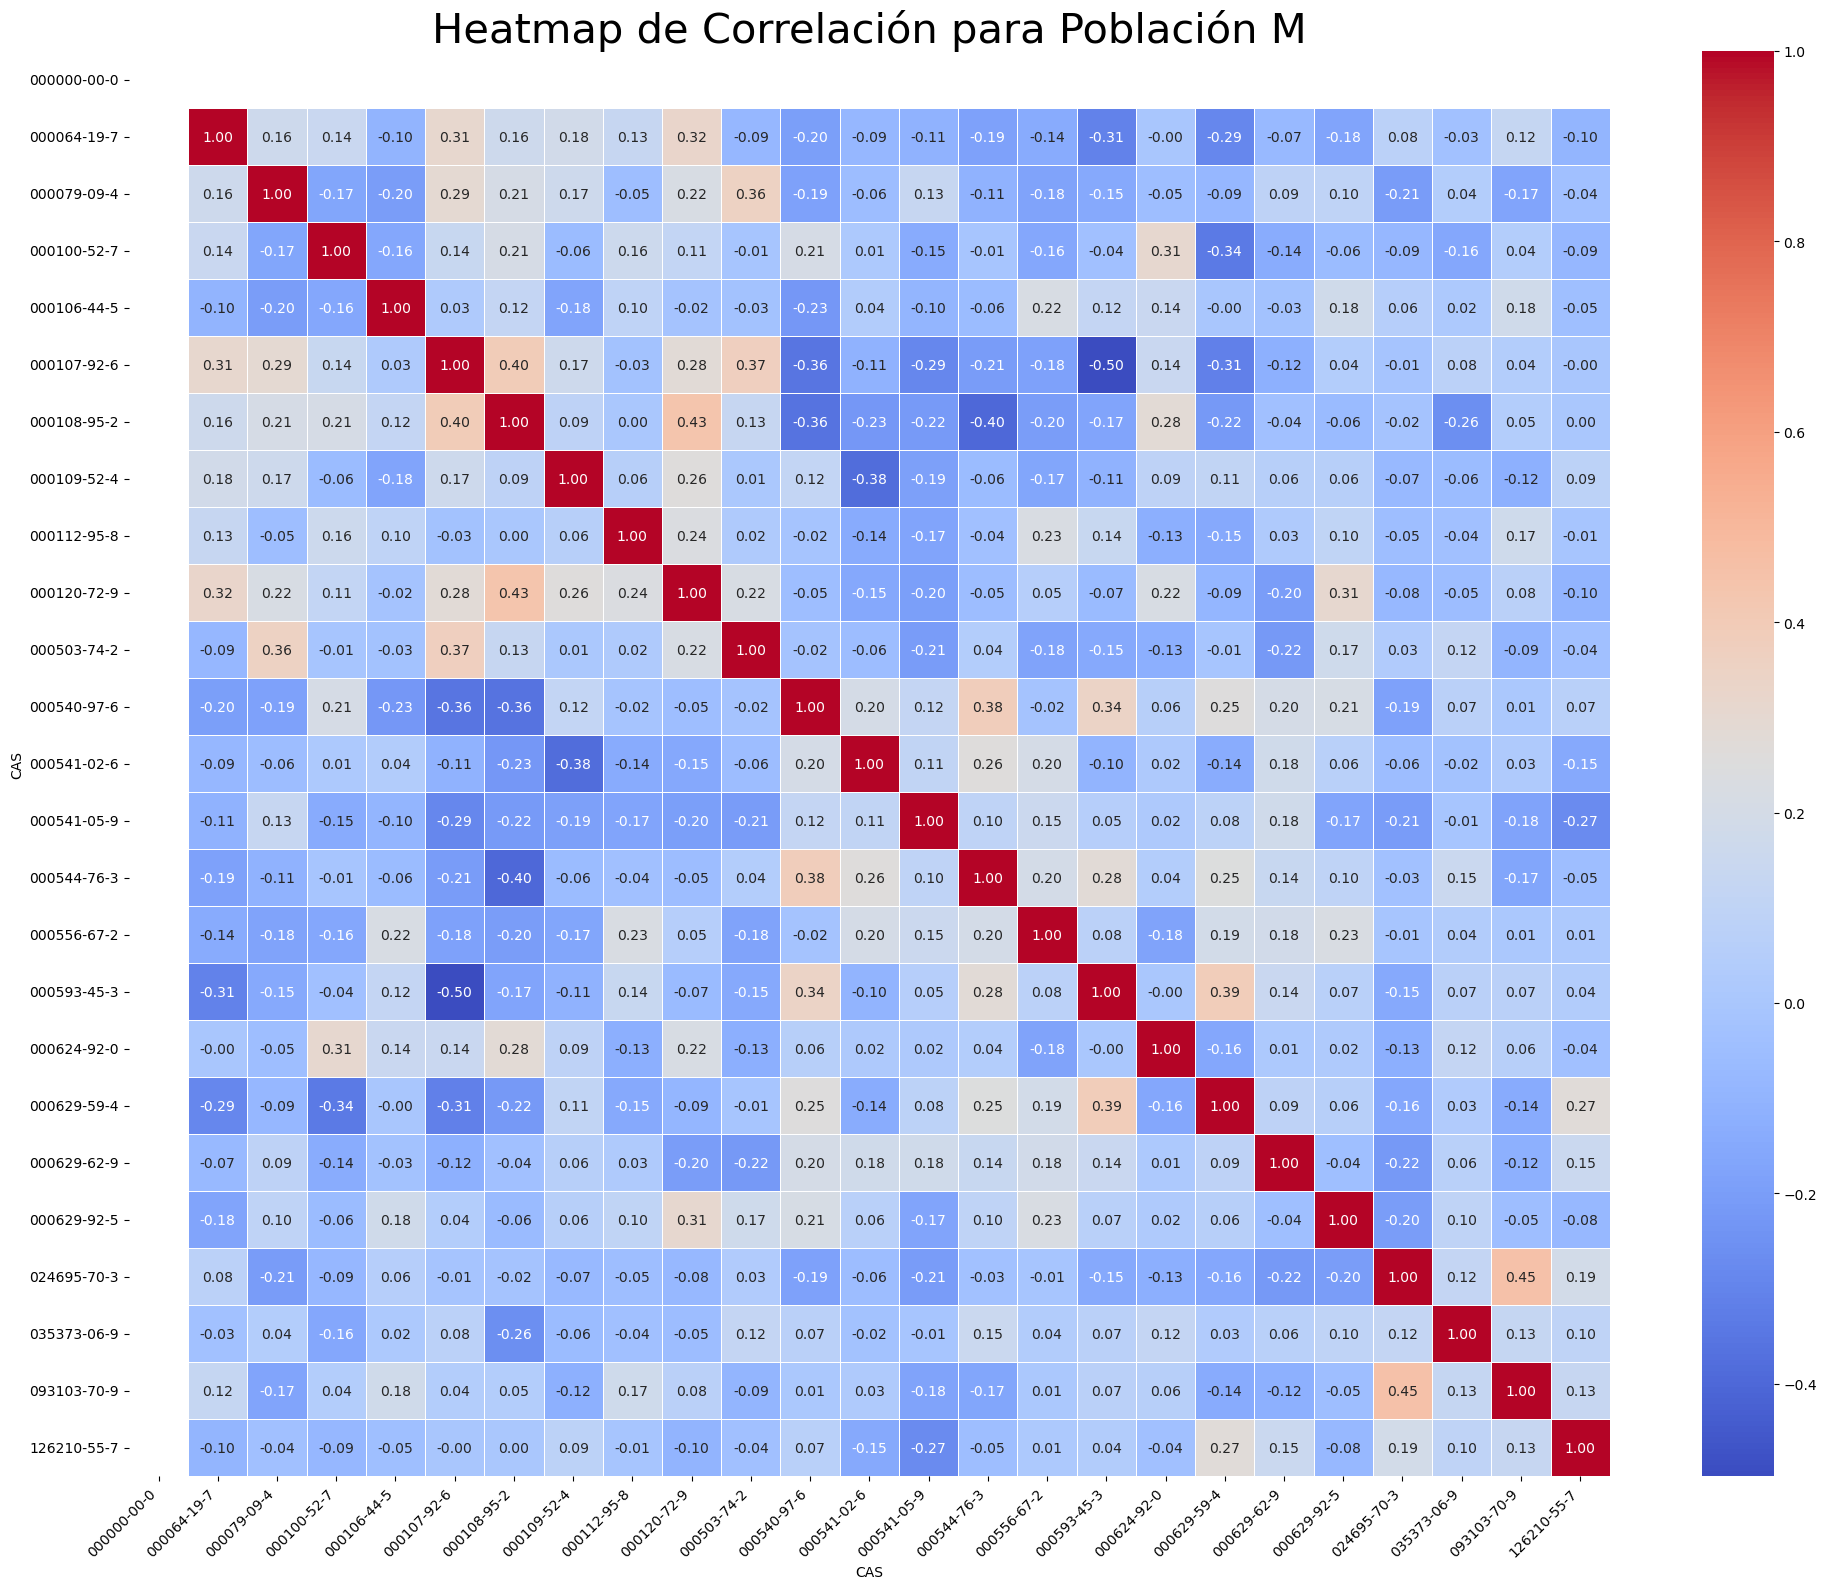

In [ ]:
# Heatmap para 'M'
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix_m, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap de Correlación para Población M', fontsize=30)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Visualización de la Matriz de Correlación (Población s)

Se genera un **mapa de calor (heatmap)** para visualizar las relaciones entre las variables de la población de control (S).

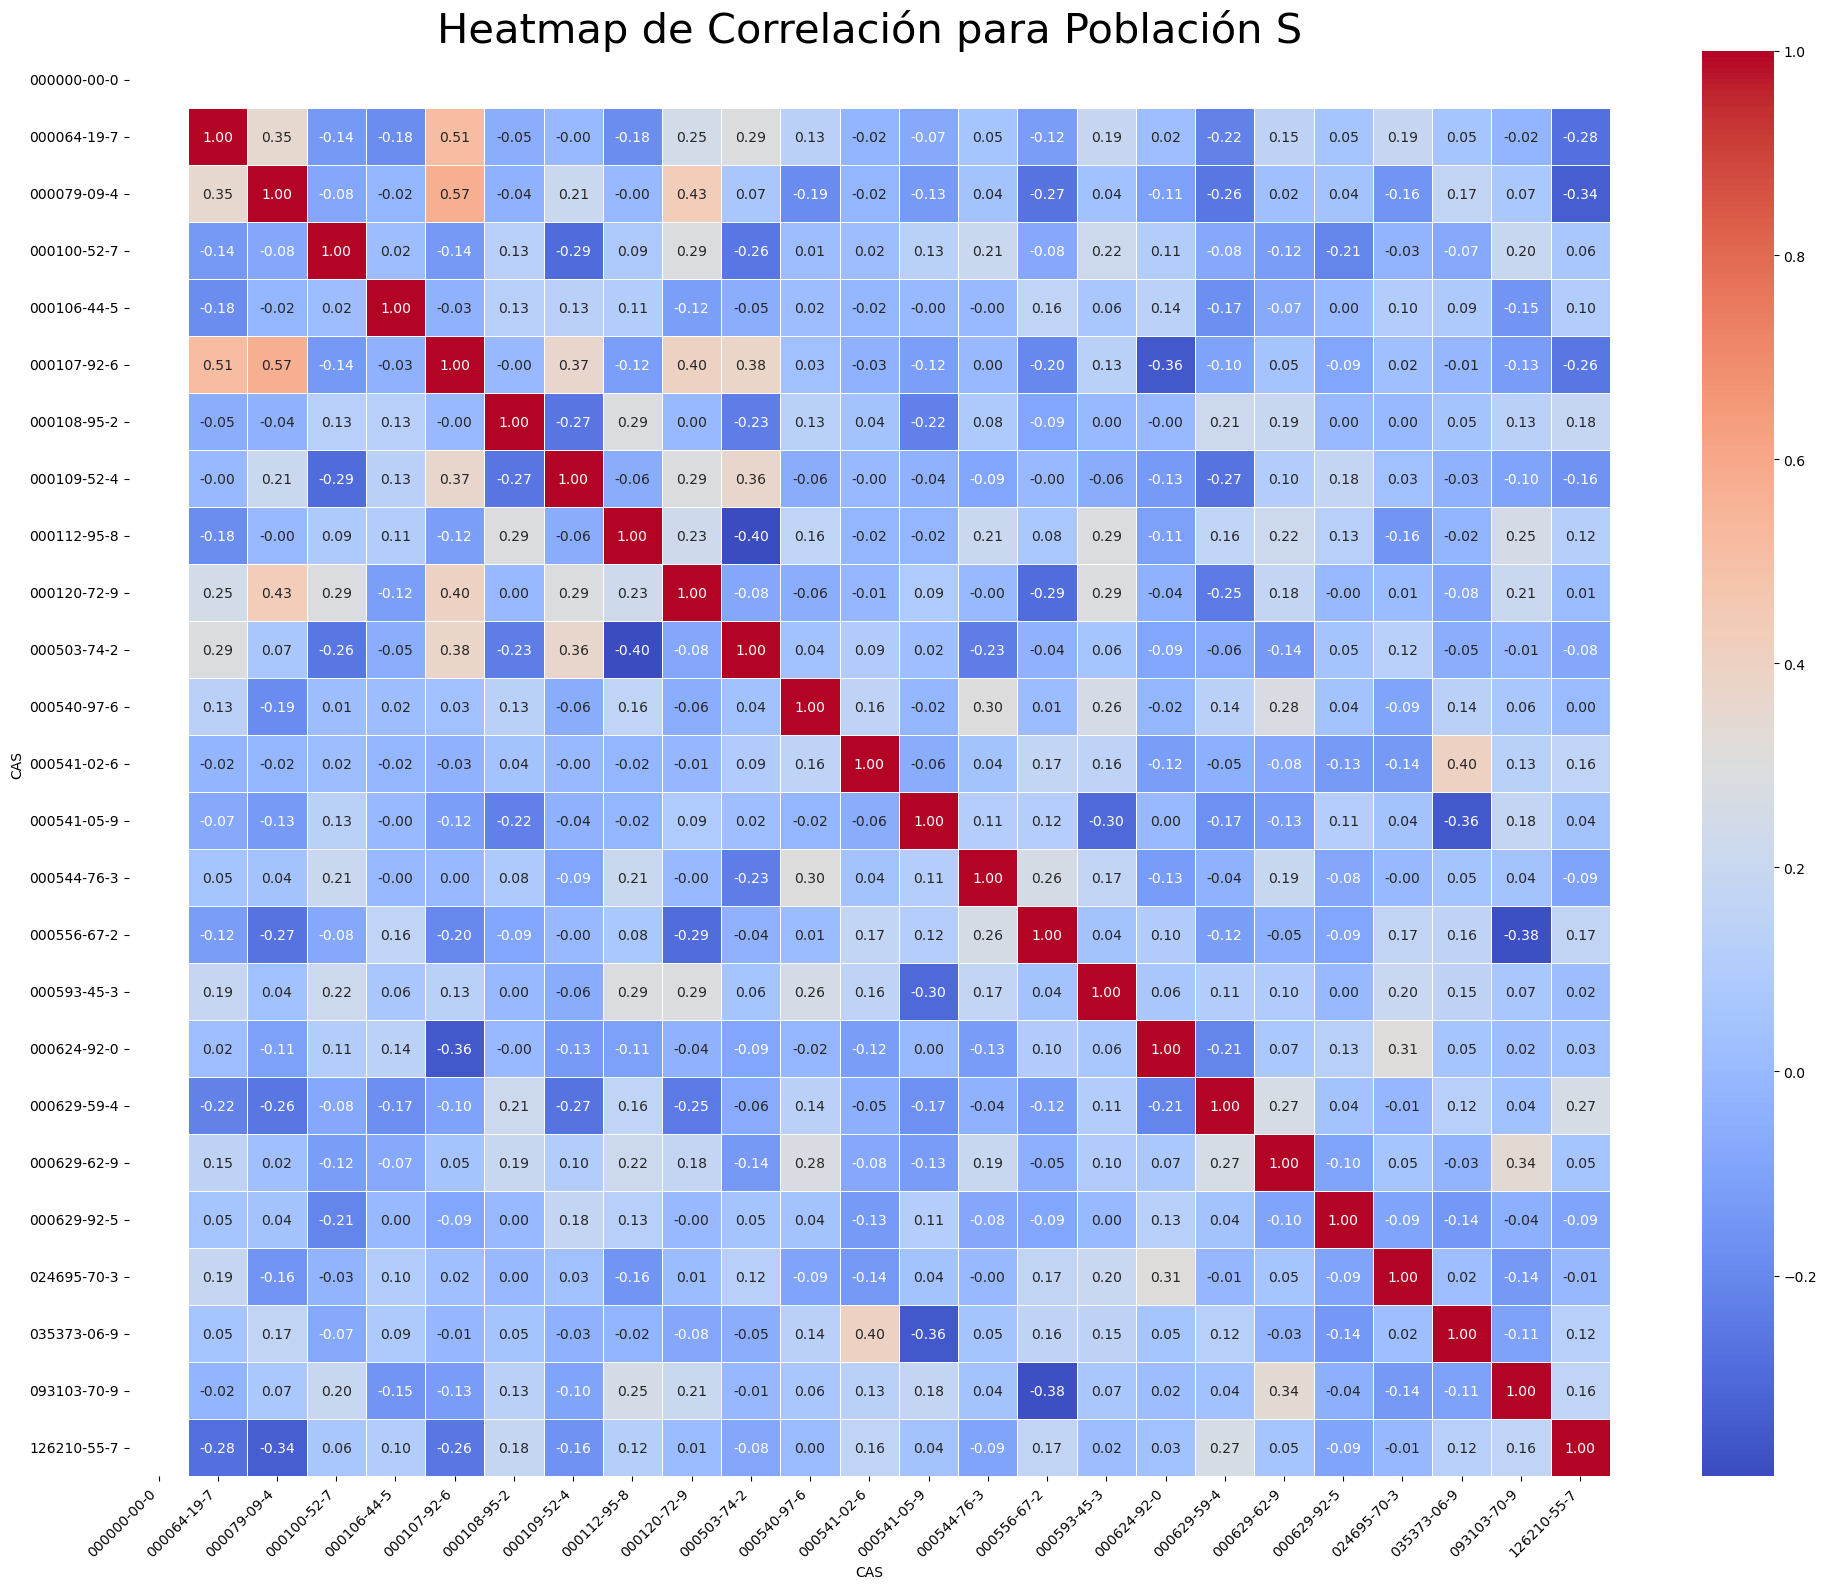

In [30]:
# Heatmap para 'S'
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix_s, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap de Correlación para Población S', fontsize=30)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Visualización de la Matriz de Correlación (Población P)

Se genera un **mapa de calor (heatmap)** para visualizar las relaciones entre las variables de la población de control (P).

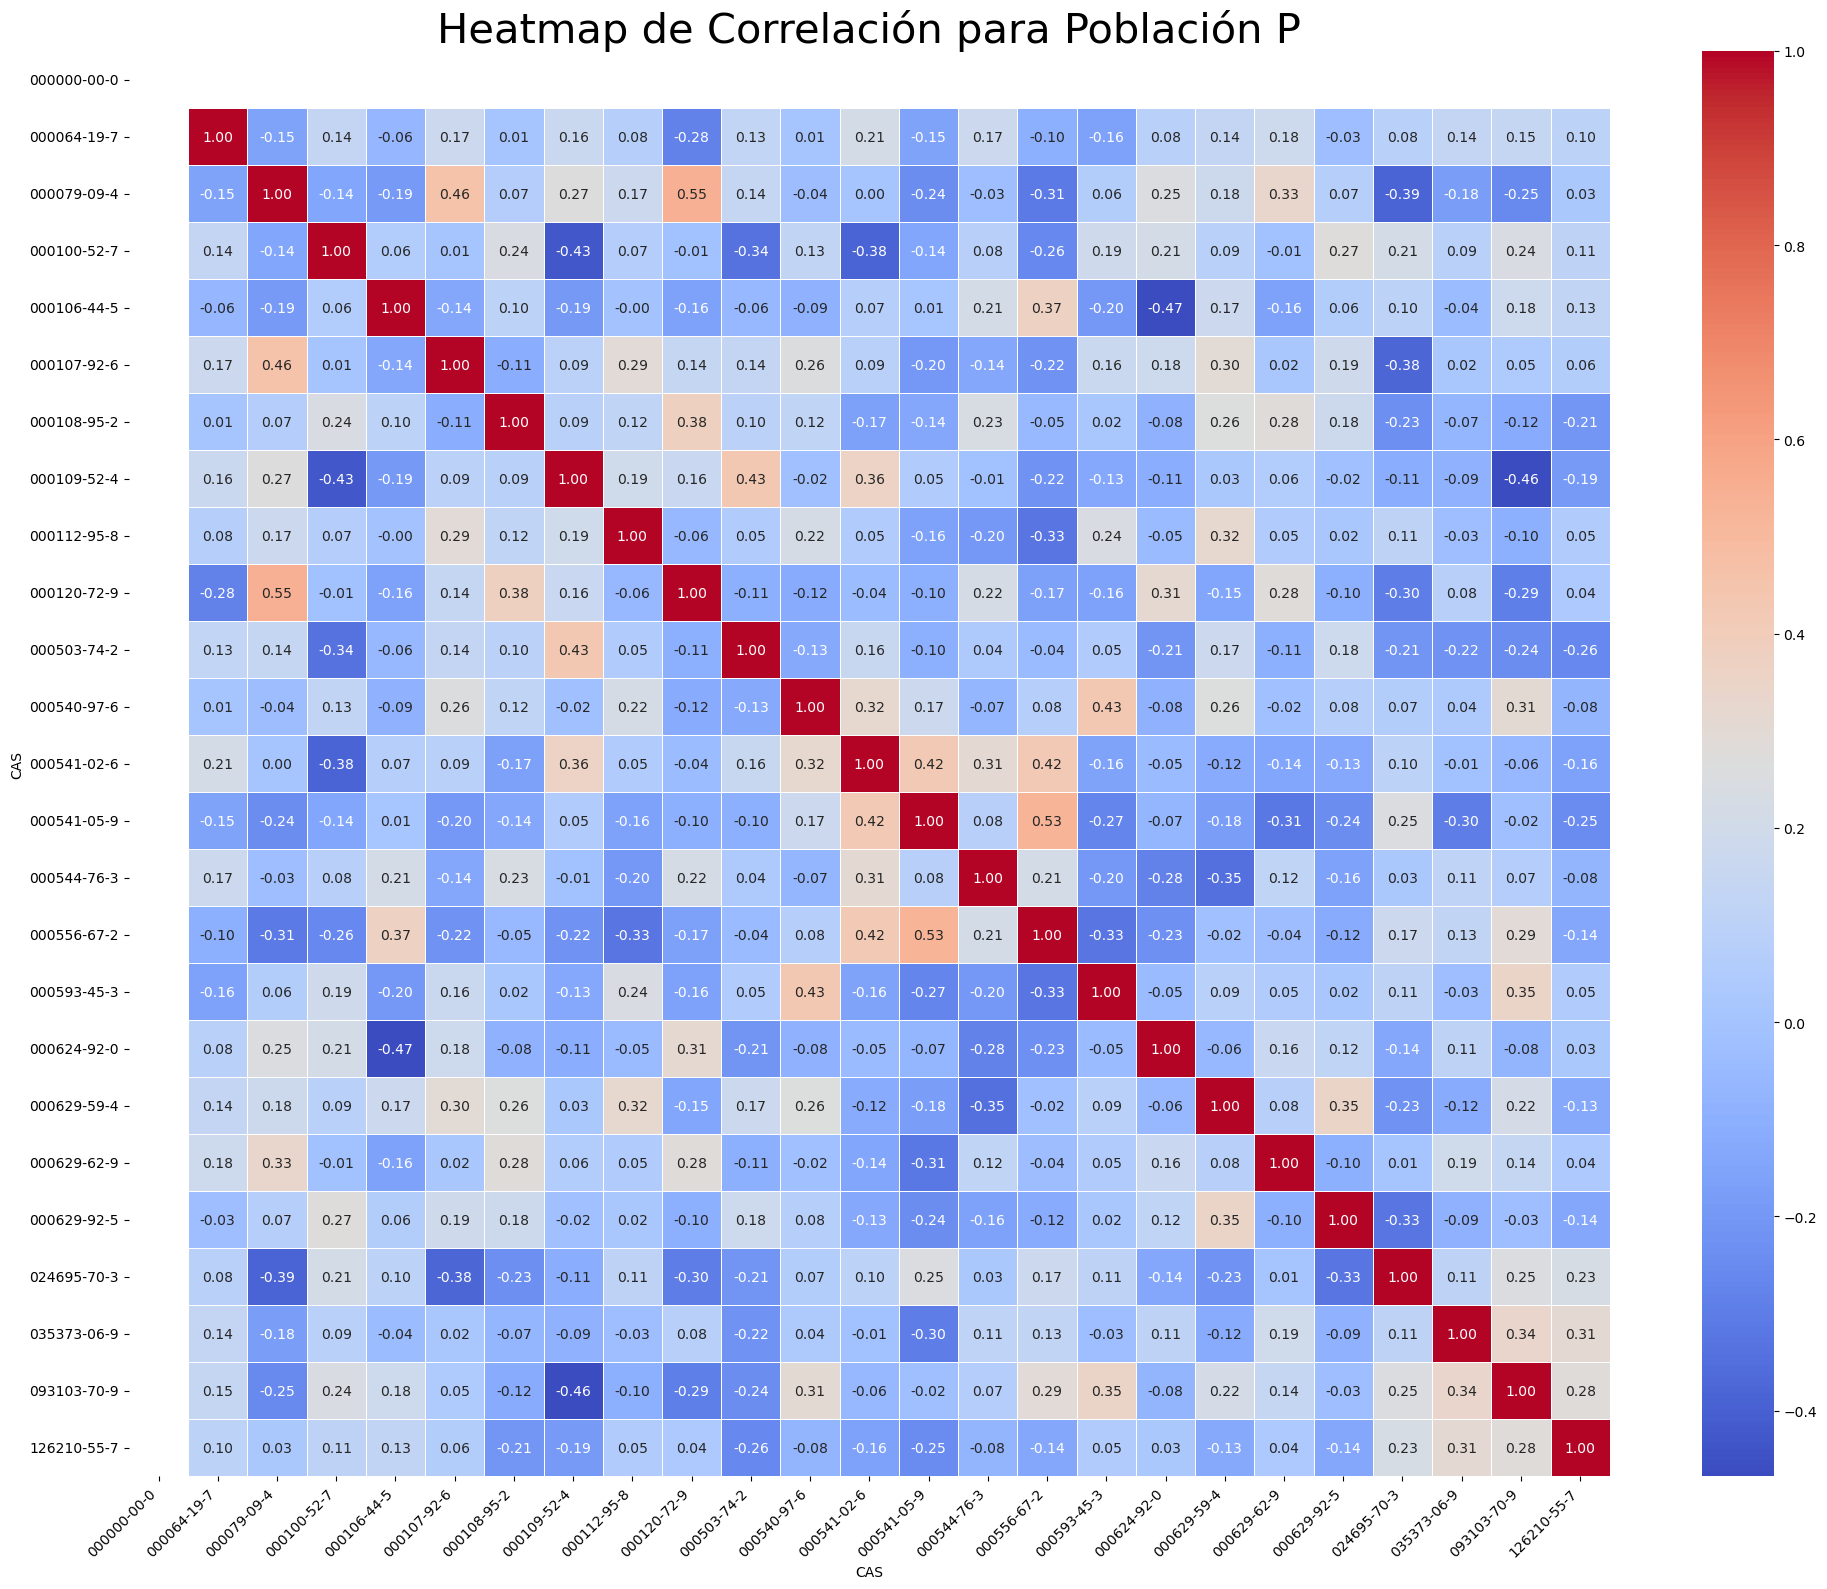

In [31]:
# Heatmap para 'P'
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix_p, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap de Correlación para Población P', fontsize=30)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Diferencias de Correlación diferencia entre S - M
Esta celda genera mapas de calor (heatmaps) para visualizar las diferencias calculadas anteriormente. 

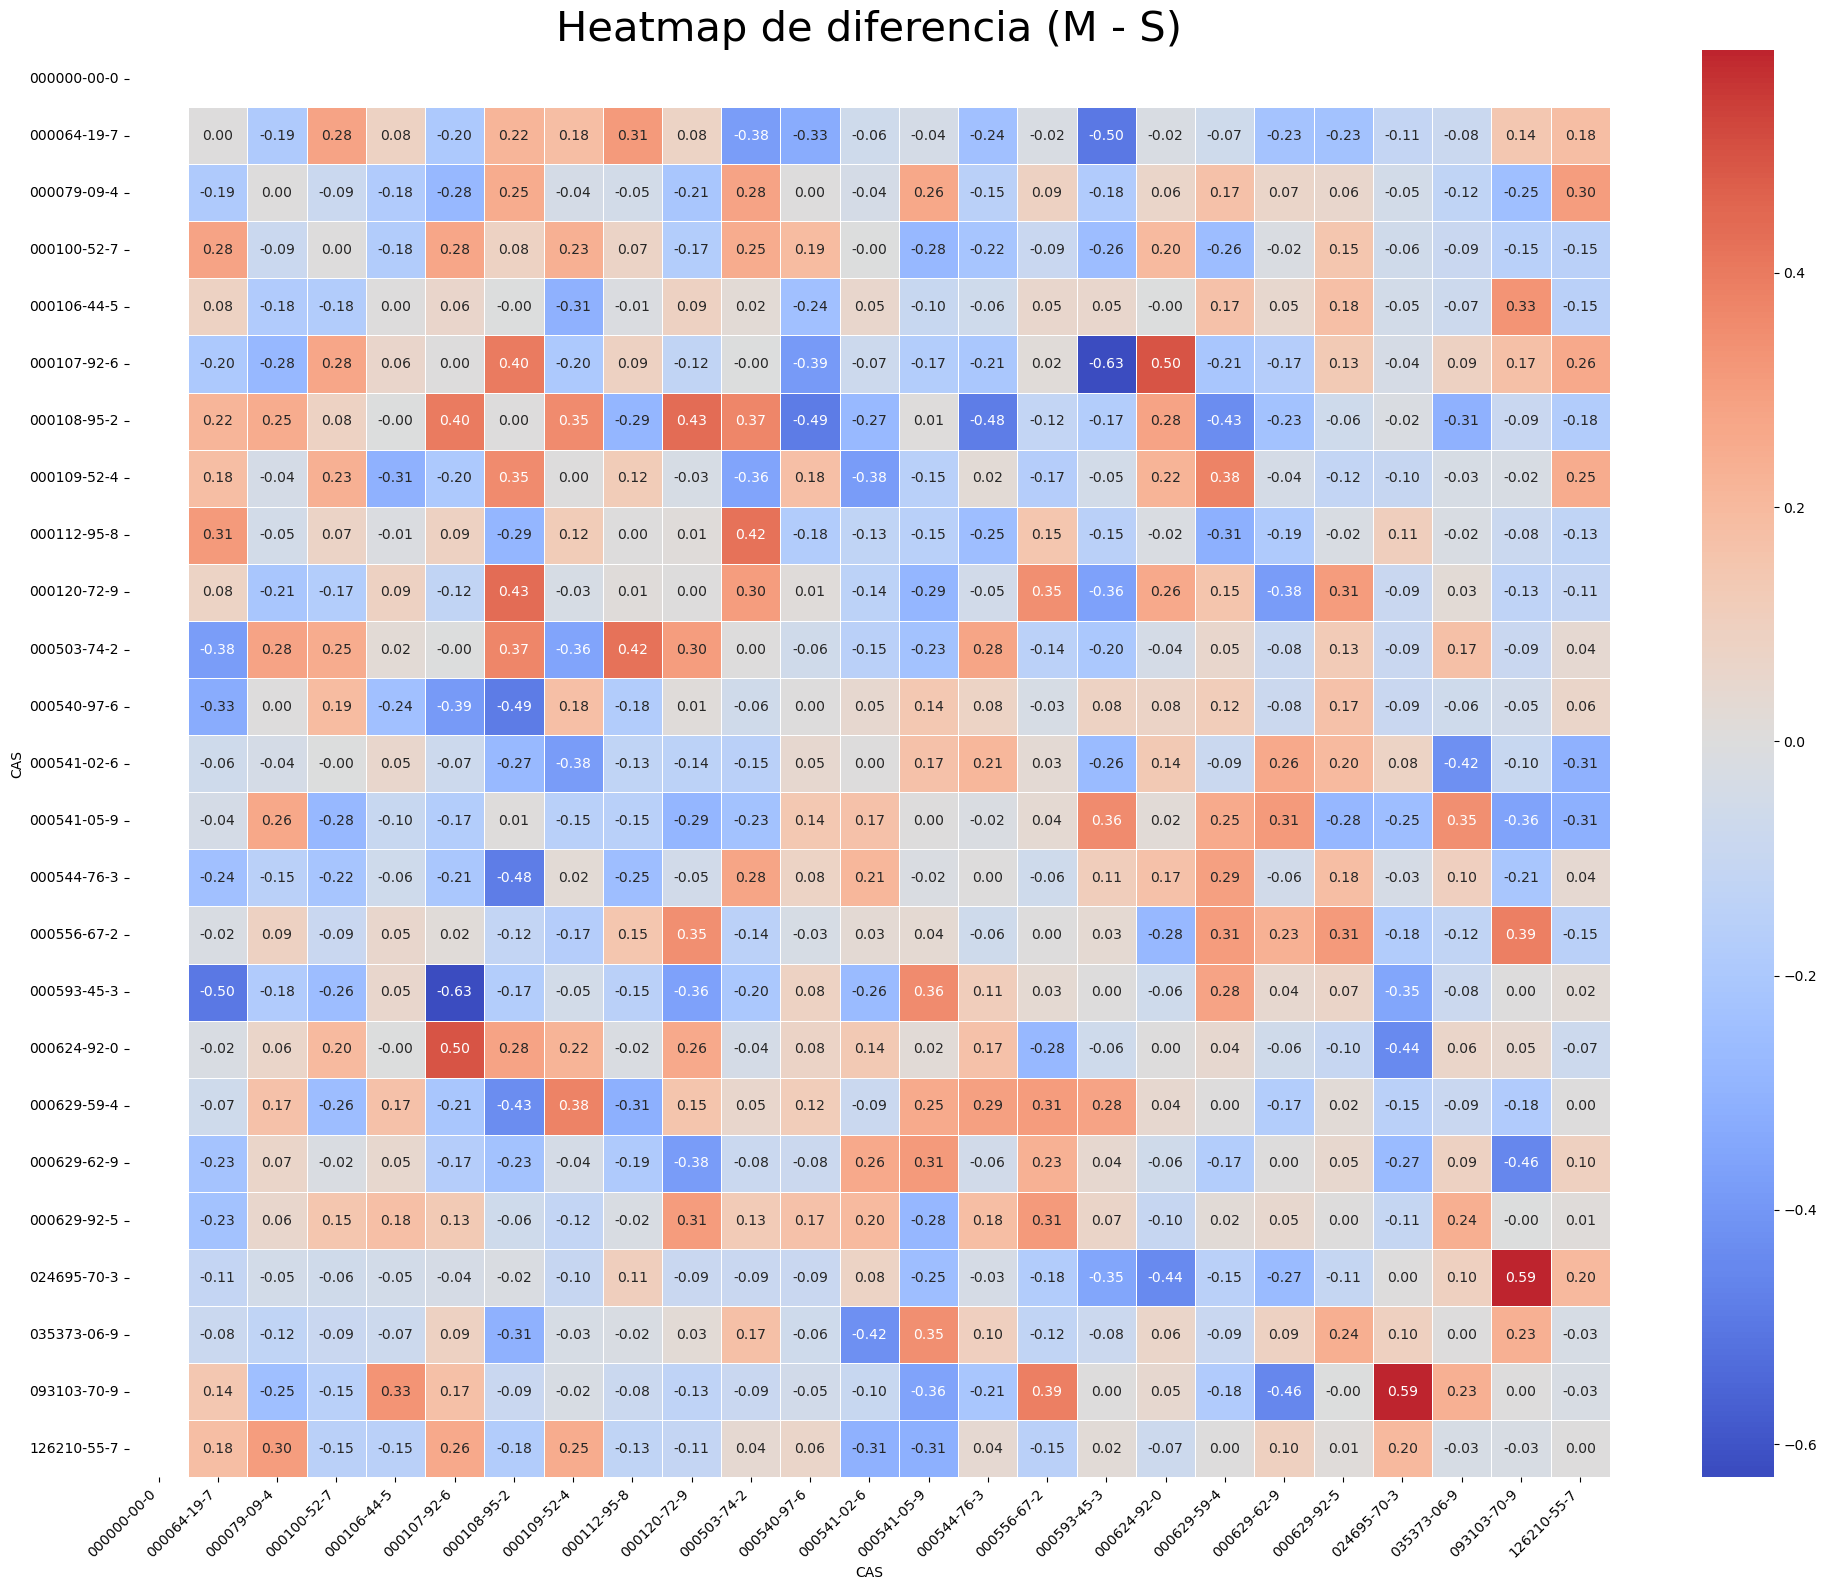

In [32]:
# Heatmap para diferencia entre S - M
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_diff, annot=True, cmap='coolwarm', fmt=".2f", center=0, linewidths=0.5)
plt.title('Heatmap de diferencia (M - S)', fontsize=30)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Diferencias de Correlación diferencia entre M - P
Esta celda genera mapas de calor (heatmaps) para visualizar las diferencias calculadas anteriormente. 

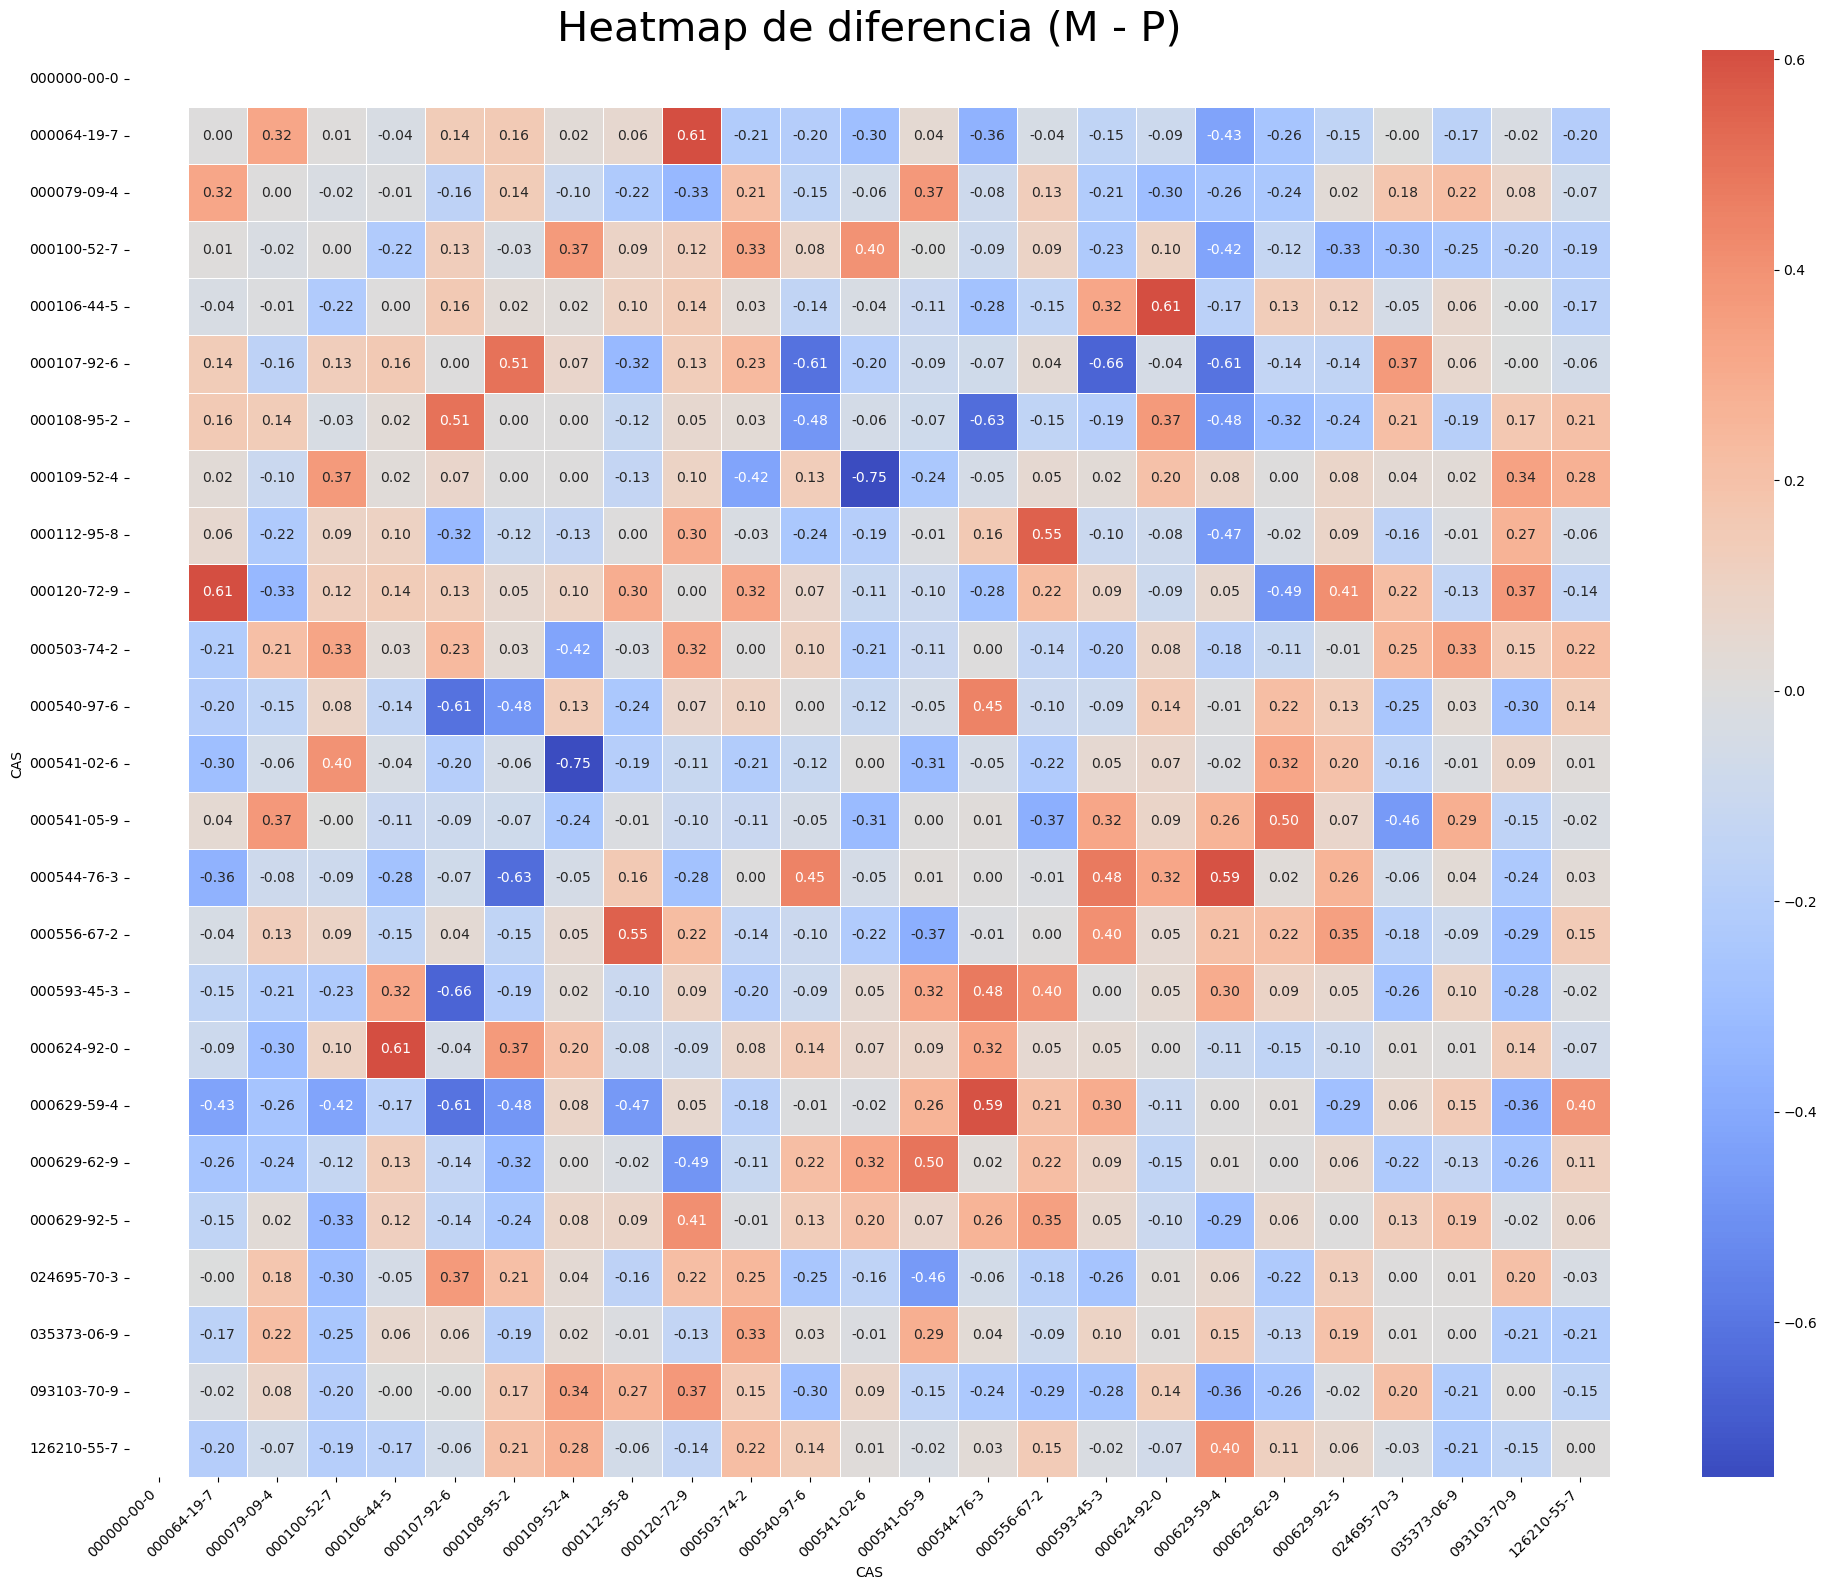

In [33]:
# Heatmap para diferencia entre (M - P)
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_diff_M_P, annot=True, cmap='coolwarm', fmt=".2f", center=0, linewidths=0.5)
plt.title('Heatmap de diferencia (M - P)', fontsize=30)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Diferencias de Correlación diferencia entre S - P
Esta celda genera mapas de calor (heatmaps) para visualizar las diferencias calculadas anteriormente. 

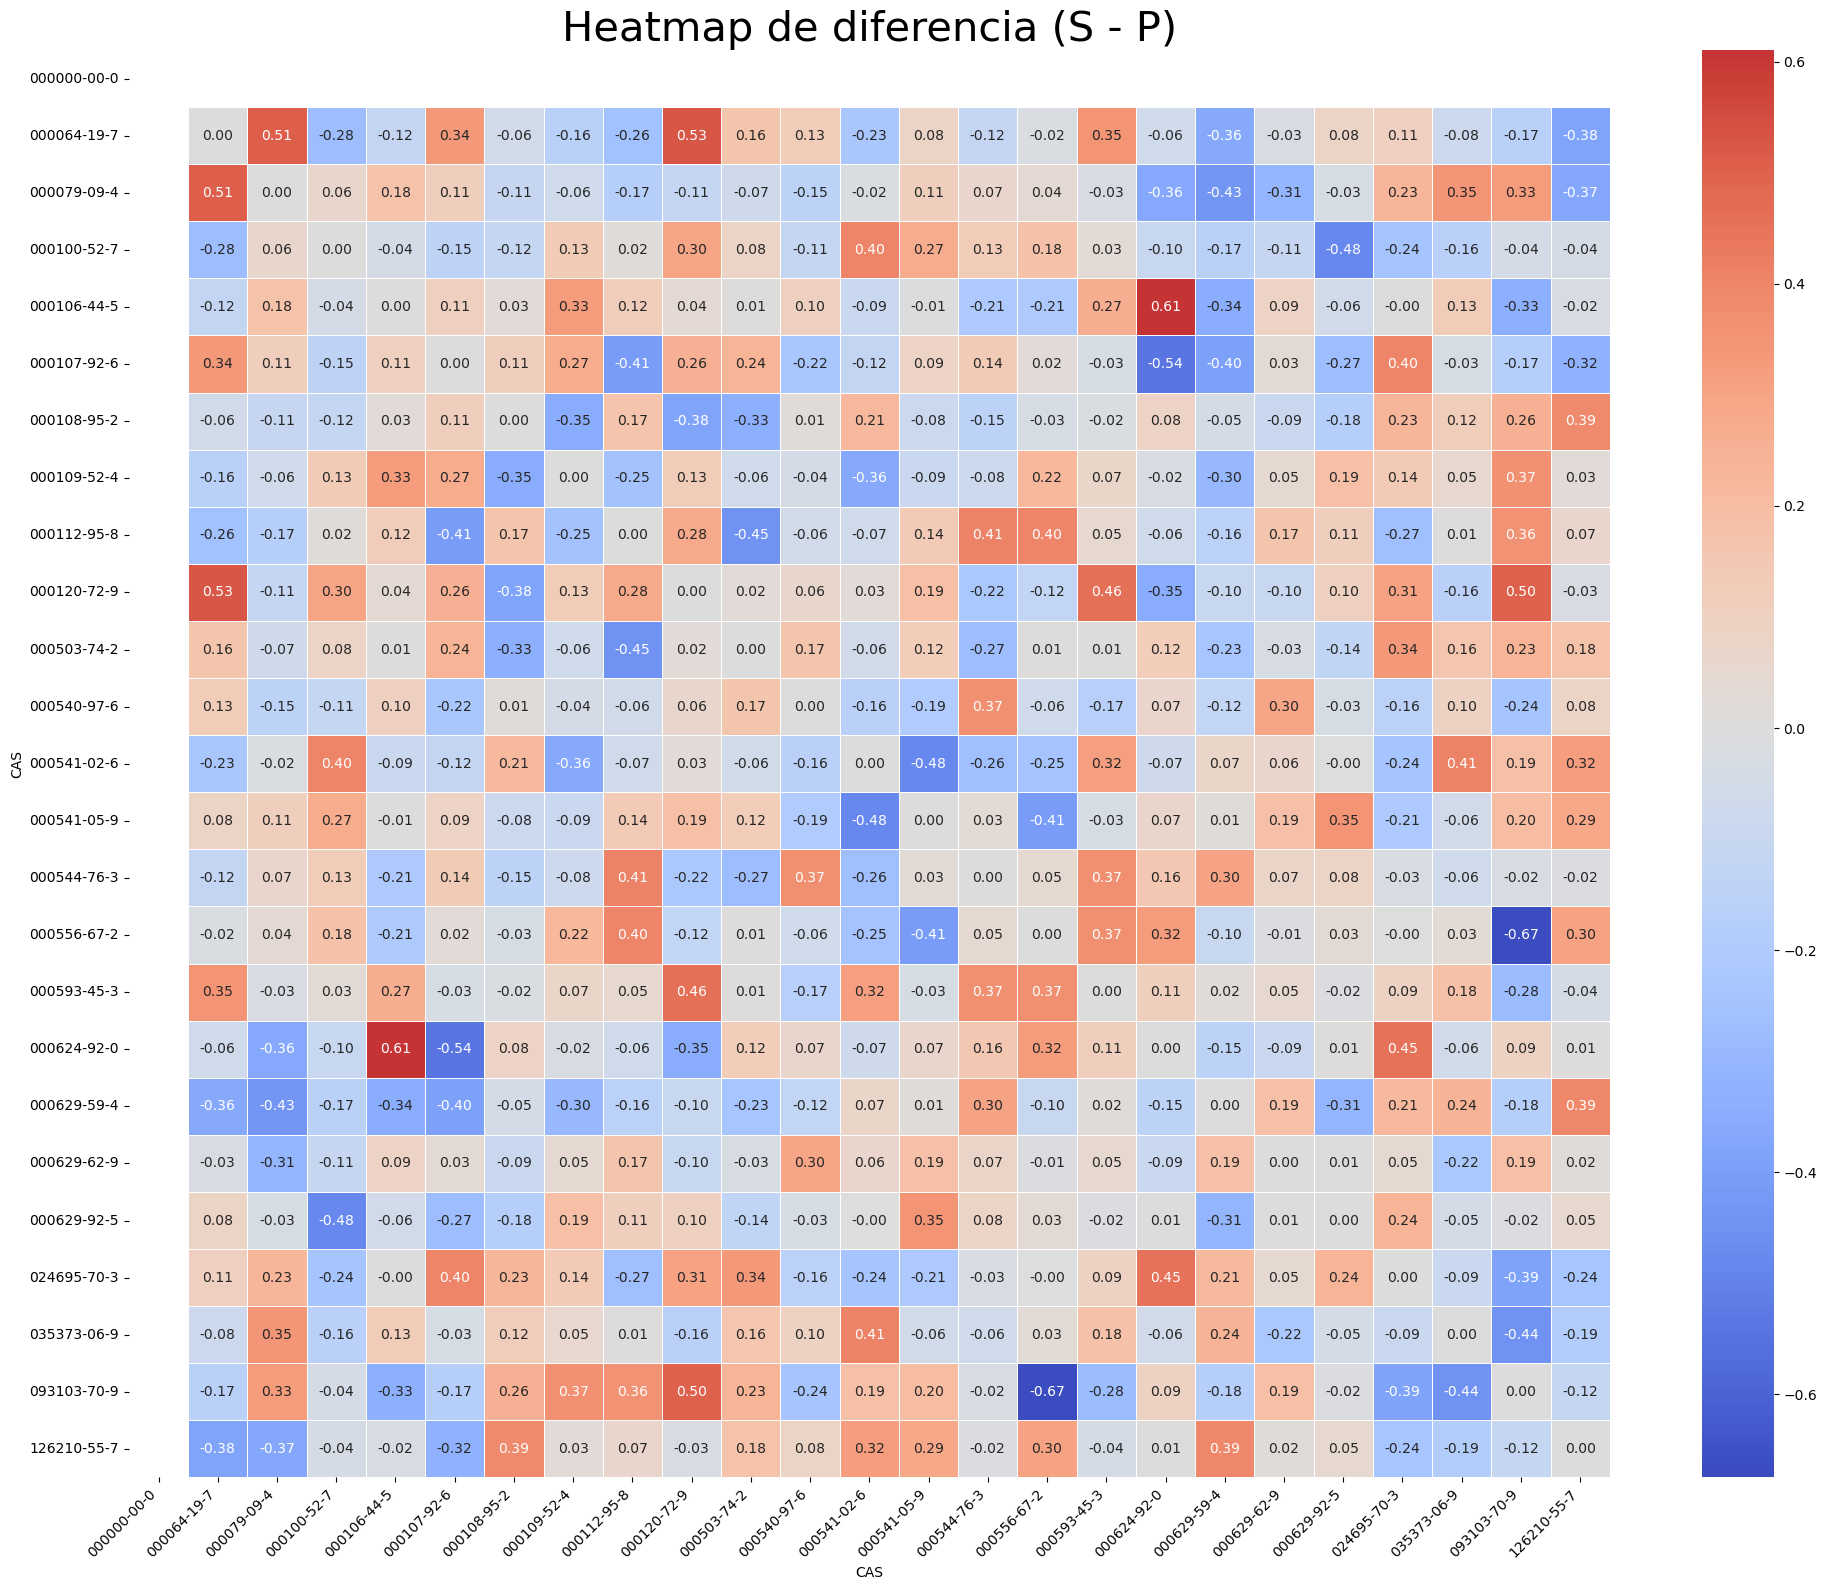

In [34]:
# Heatmap para diferencia entre (S - P)
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_diff_S_P, annot=True, cmap='coolwarm', fmt=".2f", center=0, linewidths=0.5)
plt.title('Heatmap de diferencia (S - P)', fontsize=30)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()